## The cosine similarity based on Morgan Fingerprints

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### load precomputed Morgan Fingerprints

In [2]:
df = pd.read_parquet('molecular_descriptors_raw_models_.parquet')

In [3]:
df

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,ChyLine_l2-4_OCO,ChyLine_l2-4_Brc,ChyLine_l2-4_OCOC,ChyLine_l2-4_N#CCC,ChyLine_l2-4_N#C,ChyLine_l2-4_Brc:cC,ChyLine_l2-4_SCSC,ChyLine_l2-4_SCS,ChyLine_l2-4_C=Cc,ChyLine_l2-4_O=Cc
0,26.682927,5.770088,3.219512,6.059621,153.267812,105.649934,1.844467,5.906402,3.477048,7.350701,...,0,0,0,0,0,0,0,0,0,0
1,25.935484,5.706245,2.838710,4.594982,158.057747,102.435555,1.691055,5.821371,3.354949,7.342506,...,0,0,0,0,0,0,0,0,0,0
2,23.860465,5.661247,2.930233,4.801034,157.443307,94.120542,1.670321,5.779477,3.194040,7.283060,...,0,0,0,0,0,0,0,0,0,0
3,24.764706,5.671282,2.764706,4.307190,158.718230,97.699954,1.650025,5.783676,3.183924,7.311622,...,0,0,0,0,0,0,0,0,0,0
4,24.764706,5.671282,2.882353,4.424837,158.718230,97.699954,1.650025,5.783676,3.229063,7.311622,...,0,0,0,0,0,0,0,0,0,0
5,24.893617,5.711353,3.063830,5.456265,154.834886,98.388081,1.765519,5.841011,3.214021,7.304971,...,0,0,0,0,0,0,0,0,0,0
6,24.893617,5.711353,3.106383,5.541371,154.834886,98.388081,1.765519,5.841011,3.225250,7.304971,...,0,0,0,0,0,0,0,0,0,0
7,25.708333,5.847575,3.125000,6.175926,155.472727,101.670996,1.742137,5.965856,3.413266,7.430945,...,0,0,0,0,0,0,0,0,0,0
8,32.272727,5.810739,3.250000,5.910213,153.723903,130.309772,1.900206,5.988423,3.327219,7.448031,...,0,0,0,0,0,0,0,0,0,0
9,30.000000,6.475396,3.425532,8.988180,162.407416,121.361906,1.756942,6.543164,7.194665,7.897410,...,0,0,0,0,0,0,0,0,0,0


In [4]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Separate columns to standardize and those to keep as is
cols_to_standardize = [col for col in df.columns if "C_FP_" not in col]
cols_to_keep = [col for col in df.columns if "C_FP_" in col]


# Keep the other columns as is
df_unchanged = df[cols_to_keep]

# Remove columns that are entirely zeros
df_unchanged = df_unchanged.loc[:, (df_unchanged != 0).any(axis=0)]

# Ensure original column order
df_final = df_unchanged

# Compute cosine similarity matrix between rows
similarity_matrix = cosine_similarity(df_final.values)

# Convert similarity matrix back to DataFrame for easier interpretation (optional)
similarity_df = pd.DataFrame(similarity_matrix, index=df_final.index, columns=df_final.index)
print(similarity_df)

# Calculate overall average similarity excluding self-similarity
np.fill_diagonal(similarity_matrix, np.nan)
overall_similarity = np.nanmean(similarity_matrix)
print(f"Overall average similarity in dataset: {overall_similarity:.4f}")

          0         1         2         3         4         5         6   \
0   1.000000  0.768105  0.882985  0.735006  0.762807  0.973125  0.950665   
1   0.768105  1.000000  0.779218  0.993890  0.958439  0.806967  0.811901   
2   0.882985  0.779218  1.000000  0.755462  0.831747  0.895310  0.923610   
3   0.735006  0.993890  0.755462  1.000000  0.957691  0.774134  0.781008   
4   0.762807  0.958439  0.831747  0.957691  1.000000  0.803415  0.825672   
5   0.973125  0.806967  0.895310  0.774134  0.803415  1.000000  0.968309   
6   0.950665  0.811901  0.923610  0.781008  0.825672  0.968309  1.000000   
7   0.949062  0.810532  0.922052  0.779691  0.824279  0.967757  0.989309   
8   0.959631  0.794689  0.878310  0.761753  0.790566  0.972709  0.981902   
9   0.947764  0.784862  0.868719  0.752333  0.780789  0.960680  0.969759   
10  0.972819  0.796283  0.880592  0.762258  0.791090  0.977335  0.971519   
11  0.969880  0.795169  0.880633  0.761646  0.790455  0.976450  0.975543   
12  0.960026

In [5]:
df_final

,C_FP_1,C_FP_5,C_FP_15,C_FP_24,C_FP_38,C_FP_39,C_FP_49,C_FP_50,C_FP_59,C_FP_73,...,C_FP_2000,C_FP_2013,C_FP_2016,C_FP_2028,C_FP_2029,C_FP_2030,C_FP_2031,C_FP_2033,C_FP_2038,C_FP_2047
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Find minimal similarity value (excluding diagonal)
min_similarity = np.nanmin(similarity_matrix)

print(f"Minimal similarity between any two rows: {min_similarity:.4f}")
# Find maximal similarity value (excluding diagonal)
min_similarity = np.nanmax(similarity_matrix)

print(f"Maximal similarity between any two rows: {min_similarity:.4f}")

Minimal similarity between any two rows: 0.7350
Maximal similarity between any two rows: 0.9939


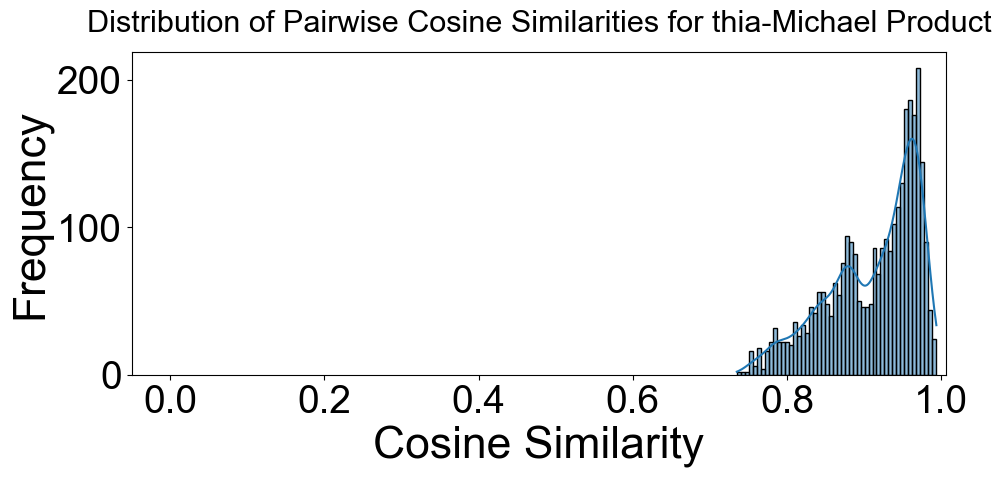

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Remove diagonal values (self-similarity = 1)
np.fill_diagonal(similarity_matrix, np.nan)

# Flatten the matrix and remove nan values to get pairwise similarities
sim_values = similarity_matrix.flatten()
sim_values = sim_values[~np.isnan(sim_values)]

# Set a clean font for better readability
plt.rcParams['font.family'] = 'Arial'  # Or 'Helvetica', 'sans-serif', etc.

# Create figure with specified size
plt.figure(figsize=(10, 5))

# Plot the distribution using seaborn
sns.histplot(sim_values, bins=50, kde=True)

# Customize font sizes for better visibility
plt.title('Distribution of Pairwise Cosine Similarities for thia-Michael Product', fontsize=22, pad=15)
plt.xlabel('Cosine Similarity', fontsize=32)
plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.xlim(-0.05)
plt.ylabel('Frequency', fontsize=32)
plt.tick_params(axis='both', which='major', labelsize=28)  # Larger tick labels

# Adjust layout to prevent clipping
plt.tight_layout(pad=1.5)  # Add padding to avoid text cutoff

# Save to file with high DPI and tight bounding box
plt.savefig('cosine_similarities_II.svg', bbox_inches='tight', format='svg', dpi=300)

# Show the plot (optional, comment out if only saving)
plt.show()

# Close figure to free memory
plt.close()